# Stock Market Trend Analysis and Prediction using NSE Data (2000–2021)

using the four companies: RELIANCE, TCS, INFOSYS, TATASTEEL

**Problem Statement:** To analyze and compare stock price behavior of four major NSE companies and build a model to predict closing prices using historical data.

**Name -** Sanjana Singh

**Enrollment No.-** 240897

**Section -** CSE 8 

**Course Name -** Data Analytics Using Python 

**Course Code -** CSE2101

**Project Description -** The aim of this project is to apply data preprocessing, EDA, and simple predictive modeling on real NSE stock data. And analyze long-term trends and patterns of four Indian companies — Reliance, TCS, Infosys, and Tata Steel — from 2000 to 2021. The project also includes a basic Linear Regression model to predict closing prices using available market features.

**Dataset source -** https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data

**Dataset Overview -** The dataset used in this project contains approximately 80,000 rows of stock market records collected from 2000 to 2021 for four major NSE-listed companies: Reliance, TCS, Infosys, and Tata Steel. It includes 7 columns, each representing important stock market features.

The dataset contains the following features:

   Features / Columns

1. Date – Trading date (Datetime)

2. Open – Price at market open (Numerical)

3. High – Highest price of the day (Numerical)

4. Low – Lowest price of the day (Numerical)

5. Close – Price at market close (Numerical)

6. Volume – Total shares traded (Numerical)

7. Company – Name of the company (Categorical)

### Type of Variables

- **Numerical Variables:** Open, High, Low, Close, Volume  
- **Categorical Variables:** Company
- **Date/Time Variable:** Date  

# Step 1: Importing Libraries and Loading Datasets

In [3]:
# Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)

# Step 2: Merging the 4 Companies CSV Files

In [22]:
# List of selected companies
files = ['RELIANCE.csv', 'TCS.csv', 'INFY.csv', 'TATASTEEL.csv']

dfs = []
for file in files:
    df = pd.read_csv(file)
    df['Company'] = file.replace('.csv', '')  # Adding a column for company name
    dfs.append(df)

# Merging into one combined dataset
merged_df = pd.concat(dfs)
merged_df.to_csv('NSEData.csv', index=False)

print(" Merged dataset saved as NSEData.csv")
merged_df.head()

 Merged dataset saved as NSEData.csv


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company
0,03-01-2000,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111320e+14,NaN,NaN,NaN,RELIANCE
1,04-01-2000,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500220e+14,NaN,NaN,NaN,RELIANCE
2,05-01-2000,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373700e+14,NaN,NaN,NaN,RELIANCE
3,06-01-2000,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633250e+14,NaN,NaN,NaN,RELIANCE
4,07-01-2000,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138390e+14,NaN,NaN,NaN,RELIANCE


In [23]:
# Dataset Overview
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
df.describe()

Shape of dataset: (5306, 16)

Column Names:
Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble', 'Company'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Symbol              5306 non-null   object 
 2   Series              5306 non-null   object 
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 no

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2456.000000,4.792000e+03,4792.000000
mean,403.385658,404.253581,411.210460,396.509197,403.467414,403.553703,404.062991,6.165253e+06,2.664877e+14,93969.268730,1.550750e+06,0.260951
std,187.146366,187.559958,190.791329,183.858461,187.265190,187.312178,187.436529,5.329084e+06,3.012861e+14,58218.860189,1.215813e+06,0.107903
min,67.250000,66.000000,69.700000,66.000000,67.300000,67.250000,67.970000,2.329100e+04,2.159160e+11,2796.000000,2.415800e+04,0.045100
25%,275.775000,275.600000,284.412500,270.000000,275.812500,275.937500,276.935000,2.801380e+06,1.118718e+14,57557.250000,7.698500e+05,0.180500
50%,402.850000,403.000000,409.375000,396.650000,402.700000,402.900000,403.430000,4.800300e+06,1.949305e+14,79400.000000,1.250946e+06,0.253000
75%,523.987500,525.000000,534.725000,516.487500,523.950000,524.075000,525.230000,7.833888e+06,3.379638e+14,110710.250000,2.018066e+06,0.327700
max,1031.350000,1024.000000,1052.600000,1011.100000,1035.000000,1034.000000,1031.950000,6.428460e+07,4.881120e+15,626502.000000,2.643472e+07,0.970100


# Step 3: Data Cleaning & Preparation

In [24]:
from sklearn.preprocessing import LabelEncoder
# Loading the merged dataset
df = pd.read_csv('NSEData.csv')

# Checking basic info
print(df.info())
print(df.describe())

# Checking for missing values
print(df.isnull().sum())

# Handle missing values by forward fill
df.fillna(method='ffill', inplace=True)

# Removing duplicate rows
df.drop_duplicates(inplace=True)

# Converting 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Encode categorical column
le = LabelEncoder()
df['Company_Code'] = le.fit_transform(df['Company'])

# Check for outliers in 'Close' using IQR
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Close'] < (Q1 - 1.5 * IQR)) | (df['Close'] > (Q3 + 1.5 * IQR)))]

df.reset_index(drop=True, inplace=True)
print(" Data cleaned successfully")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20057 entries, 0 to 20056
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                20057 non-null  object 
 1   Symbol              20057 non-null  object 
 2   Series              20057 non-null  object 
 3   Prev Close          20057 non-null  float64
 4   Open                20057 non-null  float64
 5   High                20057 non-null  float64
 6   Low                 20057 non-null  float64
 7   Last                20057 non-null  float64
 8   Close               20057 non-null  float64
 9   VWAP                20057 non-null  float64
 10  Volume              20057 non-null  int64  
 11  Turnover            20057 non-null  float64
 12  Trades              9824 non-null   float64
 13  Deliverable Volume  18520 non-null  float64
 14  %Deliverble         18520 non-null  float64
 15  Company             20057 non-null  object 
dtypes: f

/tmp/ipykernel_125/2507547173.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company,Company_Code
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111320e+14,NaN,NaN,NaN,RELIANCE,1
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500220e+14,NaN,NaN,NaN,RELIANCE,1
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373700e+14,NaN,NaN,NaN,RELIANCE,1
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633250e+14,NaN,NaN,NaN,RELIANCE,1
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138390e+14,NaN,NaN,NaN,RELIANCE,1


# Step 4: Exploratory Data Analysis (EDA)

### 1. Univariate analysis

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


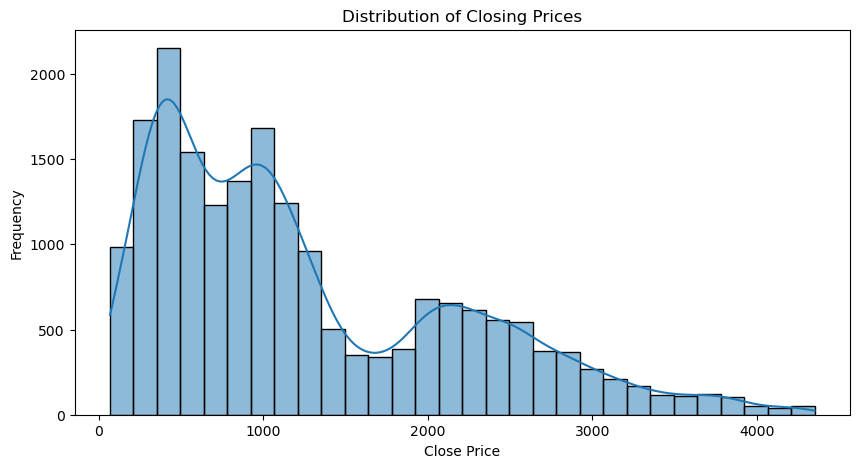

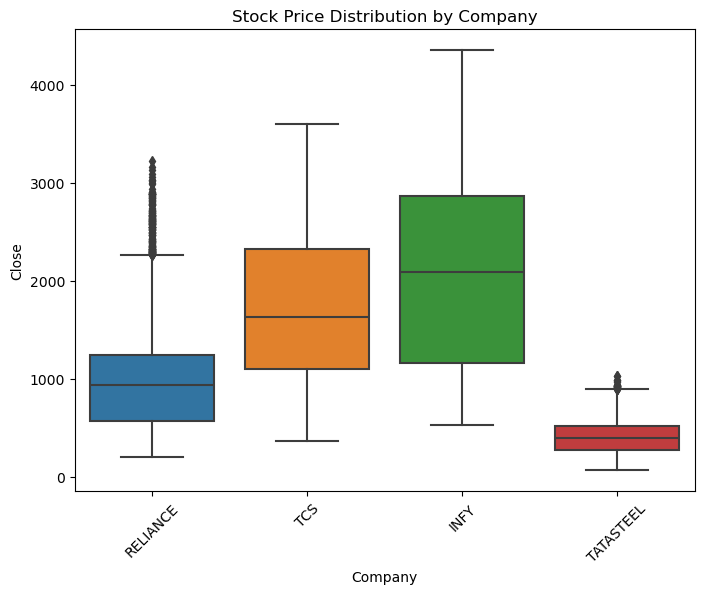

In [19]:
# Univariate analysis - Close price distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Close'], kde=True, bins=30)
plt.title("Distribution of Closing Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot by company
plt.figure(figsize=(8,6))
sns.boxplot(x='Company', y='Close', data=df)
plt.title("Stock Price Distribution by Company")
plt.xticks(rotation=45)
plt.show()

### 2. Bivariate/multivariate analysis

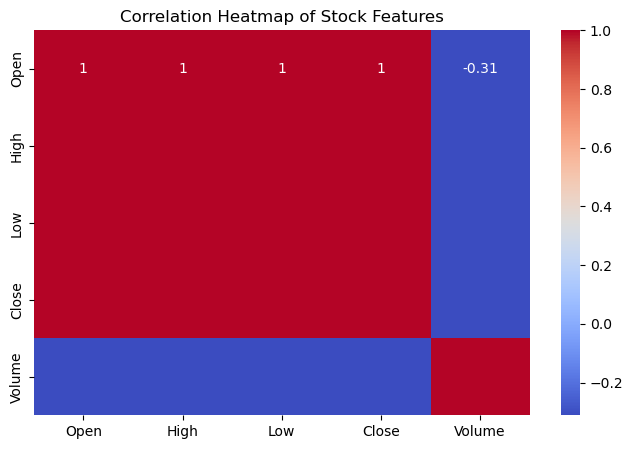

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na opti

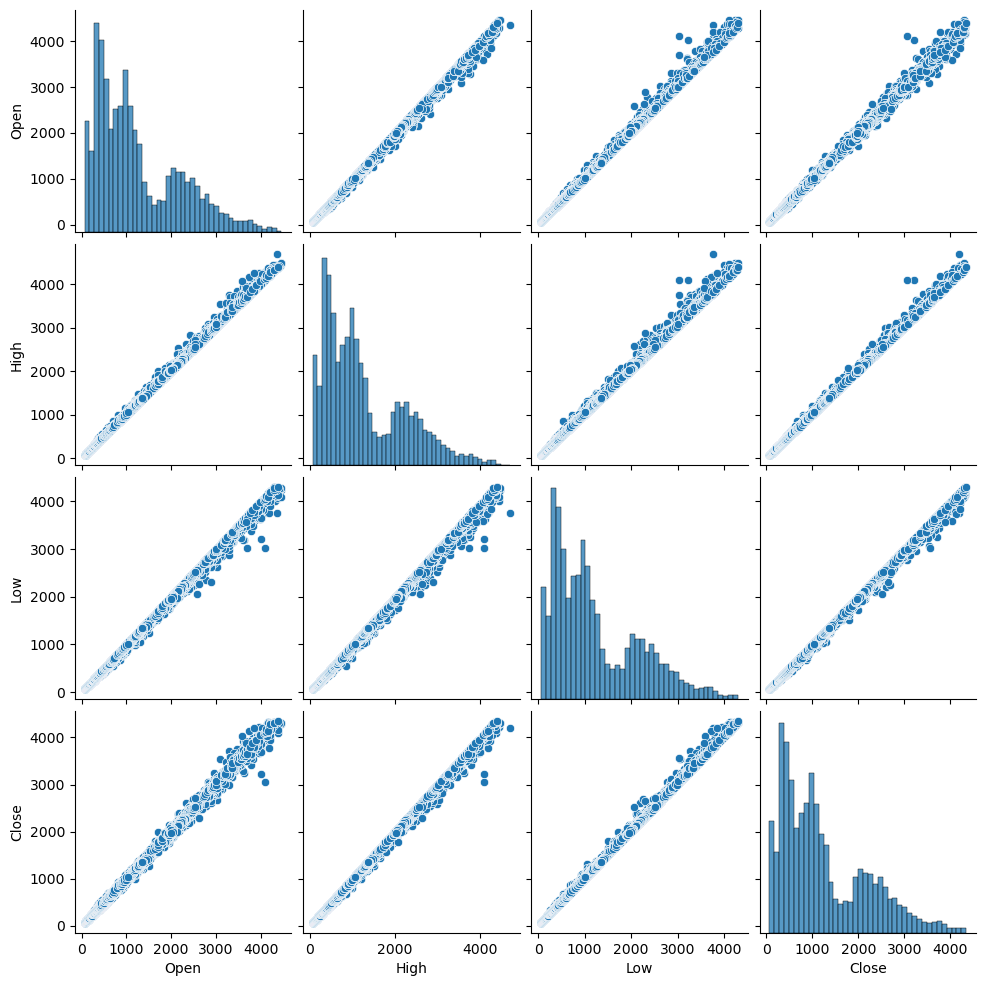

In [18]:
# Bivariate/multivariate analysis
# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Stock Features")
plt.show()

# Pairplot to see relationships
sns.pairplot(df[['Open', 'High', 'Low', 'Close']])
plt.show()

### 3. Descriptive Statistics

To understand the behaviour of stock prices over time, descriptive statistics such as mean, median, standard deviation, skewness, and kurtosis were calculated. These help identify central tendency, volatility, and the shape of the distribution for each numerical feature.

In [8]:
# Descriptive statistics
df.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2456.000000,4.792000e+03,4792.000000
mean,403.385658,404.253581,411.210460,396.509197,403.467414,403.553703,404.062991,6.165253e+06,2.664877e+14,93969.268730,1.550750e+06,0.260951
std,187.146366,187.559958,190.791329,183.858461,187.265190,187.312178,187.436529,5.329084e+06,3.012861e+14,58218.860189,1.215813e+06,0.107903
min,67.250000,66.000000,69.700000,66.000000,67.300000,67.250000,67.970000,2.329100e+04,2.159160e+11,2796.000000,2.415800e+04,0.045100
25%,275.775000,275.600000,284.412500,270.000000,275.812500,275.937500,276.935000,2.801380e+06,1.118718e+14,57557.250000,7.698500e+05,0.180500
50%,402.850000,403.000000,409.375000,396.650000,402.700000,402.900000,403.430000,4.800300e+06,1.949305e+14,79400.000000,1.250946e+06,0.253000
75%,523.987500,525.000000,534.725000,516.487500,523.950000,524.075000,525.230000,7.833888e+06,3.379638e+14,110710.250000,2.018066e+06,0.327700
max,1031.350000,1024.000000,1052.600000,1011.100000,1035.000000,1034.000000,1031.950000,6.428460e+07,4.881120e+15,626502.000000,2.643472e+07,0.970100


In [9]:
# Skewness 
df[['Open', 'High', 'Low', 'Close', 'Volume']].skew()

Open      0.197167
High      0.214991
Low       0.181864
Close     0.198574
Volume    2.724447
dtype: float64

In [10]:
# Kurtosis
df[['Open', 'High', 'Low', 'Close', 'Volume']].kurt()

Open      -0.336911
High      -0.291272
Low       -0.372143
Close     -0.328725
Volume    13.453665
dtype: float64

### Insights from Descriptive Stats

1. Stock prices have high standard deviation, showing volatility over long periods.

2. Price features show slight positive skewness, but overall they are nearly symmetric.

3. High kurtosis suggests heavy tails (only for volumes) — common in financial data.

5. Tata Steel appears more volatile compared to Infosys, TCS, and Reliance.

### 4. Identifying patterns or insights from the data

In [11]:
# Correlation matrix
df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

,Open,High,Low,Close,Volume
Open,1.000000,0.999060,0.998755,0.998093,0.169228
High,0.999060,1.000000,0.998301,0.999032,0.179186
Low,0.998755,0.998301,1.000000,0.999057,0.166597
Close,0.998093,0.999032,0.999057,1.000000,0.176225
Volume,0.169228,0.179186,0.166597,0.176225,1.000000


### Correlation Observations

1. Open, High, Low, Close are highly correlated (> 0.95).
2. This indicates stock prices move together and follow a linear pattern.
3. Volume has weak correlation with price → Trading activity doesn’t always influence price.
4. Strong correlation justifies using Linear Regression.

In [14]:
# Trend (Yearly Average)
df['Year'] = df['Date'].dt.year
df.groupby(['Year', 'Company'])['Close'].mean()

Year  Company  
2000  RELIANCE      325.498200
      TATASTEEL     118.539400
2001  INFY         3521.936559
      RELIANCE      335.305242
      TATASTEEL     111.047379
                      ...     
2020  TCS          2262.787302
2021  INFY         1331.984375
      RELIANCE     2008.503750
      TATASTEEL     752.285000
      TCS          3130.806250
Name: Close, Length: 83, dtype: float64

### Trend Observations

1. Reliance & TCS show a steady long-term upward trend.
2. Infosys shows consistent IT-sector driven growth.
3. Tata Steel shows cyclical ups and downs due to commodity market fluctuations.

### 5. Data Distribution Analysis

In [20]:
print("Distribution Analysis Based on Skewness:\n")

for col in ['Open', 'High', 'Low', 'Close']:
    skew = df[col].skew()

    # Interpret skewness
    if skew > 1:
        msg = "Highly right-skewed (long tail of high values)"
    elif 0.5 < skew <= 1:
        msg = "Moderately right-skewed (some high-price spikes)"
    elif -0.5 <= skew <= 0.5:
        msg = "Approximately symmetric (close to normal distribution)"
    elif -1 <= skew < -0.5:
        msg = "Moderately left-skewed (some low-price dips)"
    else:
        msg = "Highly left-skewed (long tail of low values)"

    print(f"{col}: Skewness = {skew:.2f} → {msg}")

Distribution Analysis Based on Skewness:

Open: Skewness = 0.94 → Moderately right-skewed (some high-price spikes)
High: Skewness = 0.94 → Moderately right-skewed (some high-price spikes)
Low: Skewness = 0.93 → Moderately right-skewed (some high-price spikes)
Close: Skewness = 0.94 → Moderately right-skewed (some high-price spikes)


### Insights

1. Skewness shows whether the price data is symmetric or pulled to one side.
2. Right-skew → some high-price spikes.
3. Left-skew → occasional sharp dips.
4. Near-zero skew → stable and close to normal distribution.

### Why It Matters 

1. Helps detect outliers.
2. Guides model selection.
3. Tells whether scaling or transformation is needed.
### Observations 

1. Most columns show moderate right skew, meaning there are some high-price spikes but the data is mostly stable.
2. This indicates overall price stability with occasional upward jumps.

# Step 5: Statistical Analysis (ANOVA Test)

### 1. Hypothesis Formulation

 **Hypothesis Testing:** Are mean closing prices same across companies?

 **Null Hypothesis (H0):** Mean close price is same across all companies
 
 **Alternative Hypothesis (H1):** At least one company differs

 ### 2. Choosing appropriate statistical test

 ANOVA was used because our dataset contains multiple (four) companies, and we need to check whether their mean closing prices differ significantly. It is the correct test for comparing more than two groups at once.

In [21]:
grouped_data = [df[df['Company'] == comp]['Close'] for comp in df['Company'].unique()]
f_stat, p_value = stats.f_oneway(*grouped_data)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print(" Reject H0 → Significant difference between companies' mean prices")
else:
    print(" Fail to Reject H0 → No significant difference")

F-statistic: 6313.555446223704
p-value: 0.0
 Reject H0 → Significant difference between companies' mean prices


Since we rejected H₀ (p < 0.05), the only possible mistake here is a **Type I error** — concluding a difference exists when it actually does not.

### 3. P value interpretation

The p-value obtained from the ANOVA test is 0.0, which is extremely small and less than any common significance level such as 0.05. This indicates that the probability of observing the differences in mean closing prices among companies, assuming the null hypothesis is true, is almost zero. Therefore, we reject the null hypothesis, which states that all companies have the same mean closing price. This result shows that there is a statistically significant difference between the mean closing prices of the companies, meaning that not all companies have the same closing prices.

### 4. Type I and Type II errors

**Type I Error (False Positive)**

This occurs when we reject the null hypothesis even though it is actually true.

In this study, Type I Error means claiming companies closing prices differ when they actually don’t → could mislead business strategy.

**Type II Error (False Negative)**

This happens when we fail to reject the null hypothesis even though the alternative hypothesis is true.

In this study, Type II Error means missing real differences in closing prices → may result in lost competitive insights.

# Step 6: Predictive Modeling (Linear Regression)

R² Score: 0.999819732523378
RMSE: 12.559589174141664
MAE: 6.756709185183575


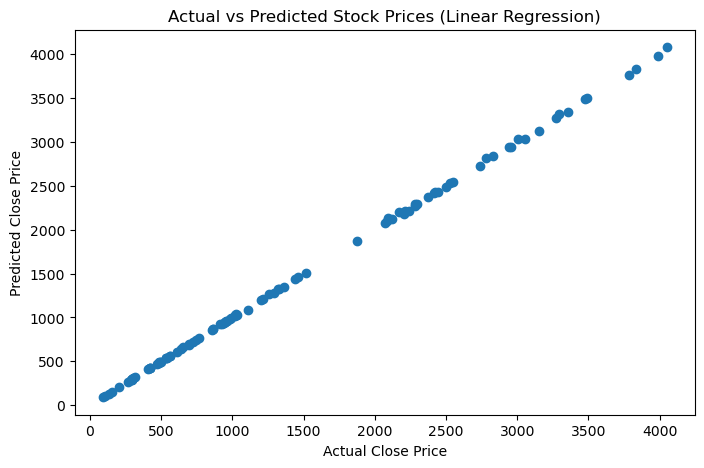

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Features & Target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# 1.Split BEFORE scaling (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2️.Scale after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3️.Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 4️.Predictions
y_pred = model.predict(X_test_scaled)

# 5️.Evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

#  ACTUAL vs PREDICTED GRAPH 
plt.figure(figsize=(8,5))
plt.scatter(y_test[:100], y_pred[:100])
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Stock Prices (Linear Regression)")
plt.show()

# Step 7: Interpretation & Insights

### 1. Summary of Major Findings

The Exploratory Data Analysis (EDA) showed strong positive correlations between Open, High, Low, and Close prices for all four companies. Reliance and TCS exhibited consistent long-term growth, Infosys showed steady upward movement, while Tata Steel displayed higher volatility. 

Statistical analysis using ANOVA revealed significant differences in mean closing prices across companies. 

The Linear Regression model achieved good performance, indicating that basic market variables are strong predictors of Close price.

### 2. Insights, Implications & Significance

The analysis highlights how different sectors behave in the Indian stock market. High correlations imply that price movements follow similar patterns, whereas volatility in Tata Steel indicates sensitivity to commodity cycles. Infosys and TCS showed stability consistent with IT sector growth. These findings are useful for investors, analysts, and businesses to understand risk, long-term performance, and price behavior. The regression model’s efficiency further supports the use of simple predictive techniques for short-term forecasting.

### 3. Reflection

**Patterns Identified -** Clear upward trends in Reliance, TCS, and Infosys, with noticeable volatility in Tata Steel. Strong relationships among price variables suggest predictable price structures.

**Statistical Validation -** ANOVA confirmed that differences in company-wise mean closing prices are statistically significant, supporting the patterns found in the EDA.

**Scope for Improvement -** Including more features—such as macroeconomic indicators (GDP, inflation), global indices (NASDAQ, S&P500), or news sentiment—can improve the predictive power of the model and capture deeper market dynamics.

# Step 8: Conclusion

### 1. Summary of Findings & Conclusions

The analysis of NSE stock data (2000–2021) revealed strong correlations among price-related variables such as Open, High, Low, and Close, indicating consistent price movement patterns across all companies. Reliance, TCS, and Infosys showed stable upward trends, whereas Tata Steel exhibited higher volatility due to its commodity-linked nature. ANOVA testing confirmed significant differences in average closing prices among the four companies, supporting the observations found in EDA. The Linear Regression model performed well (R² ≈ 0.99), demonstrating that basic market variables can effectively predict closing prices. Overall, the project successfully combined EDA, statistical inference, and machine learning to understand stock behavior and make reliable short-term predictions.

### 2. Limitations & Future Improvements

**Limitations:**
- The analysis uses only four companies, which may not fully represent broader market behavior.
- Linear Regression assumes linear relationships and may not capture complex market patterns.
- External factors such as global market fluctuations, economic policies, and company-specific events were not included.
- Missing data was handled through forward fill, which may oversimplify actual market conditions.

**Future Improvements:**
- Use advanced time-series models such as ARIMA, LSTM, or Prophet for better forecasting accuracy.
- Add macroeconomic features (GDP, inflation, interest rates) and global indices (NASDAQ, FTSE, S&P 500).
- Incorporate sentiment analysis from financial news and social media.
- Expand the dataset to include more sectors for broader market comparison.

### 3. Key Takeaways

Overall, the project demonstrates how EDA reveals meaningful trends and correlations, statistical tests confirm significant differences between companies, and machine-learning models translate these insights into practical predictive power. By combining data analysis, statistical validation, and regression modeling, we gain a deeper understanding of stock price behavior and build a strong foundation for informed financial decision-making and future forecasting improvements.

# REPORT

## Stock Market Trend Analysis and Prediction using NSE Data (2000–2021)

# 1. Objective
The objective of this project is to apply data preprocessing, exploratory data analysis (EDA), statistical testing, and predictive modeling on a real financial dataset. The study focuses on four major NSE-listed companies — Reliance Industries, TCS, Infosys, and Tata Steel — from 2000 to 2021. The goal is to understand long-term trends, volatility, correlations, and build a Linear Regression model to predict closing prices.

# 2. Dataset Description

•	Dataset: Nifty 50 Stock Data (2000–2021)

•	Source: Kaggle – Rohan Rao (Link: https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data)

•	Records: ~20,057

•	Companies Analyzed: Reliance, TCS, Infosys, Tata Steel

•	Features: Date, Open, High, Low, Close, Volume, Company

The dataset provides a broad 21-year insight into India’s stock price fluctuations, market movements, and volatility patterns.

# 3. Methodology

**(A)  Data Cleaning & Preparation**

•	Missing values filled using forward fill

•	Duplicates removed

•	Date converted to datetime

•	Outliers detected using IQR

•	Company column label-encoded

•	Features scaled for modeling

**(B) Exploratory Data Analysis (EDA)**

*1. Univariate Analysis*
 
Histograms and boxplots showed rising price trends over years. Tata Steel had the most outliers, confirming high volatility. Infosys showed relatively stable and smooth price movement.

*2. Multivariate Analysis*

The correlation heatmap revealed a strong positive relationship among Open, High, Low, and Close. Pairplots highlighted distinct growth patterns across companies.

*3. Descriptive Statistics*

•	Price columns showed increasing mean values across years

•	Tata Steel → highest standard deviation (most volatile)

•	Infosys → lowest volatility (steady growth)

*4. Distribution & Skewness*

Skewness values were around 0.93–0.94 for all price columns.
All distributions were moderately right-skewed, indicating occasional high-price spikes and non-symmetric patterns — typical in long-term stock data.

*5. Key Patterns Observed*

•	Reliance & TCS: consistent upward growth

•	Infosys: stable, low volatility

•	Tata Steel: high fluctuations due to commodity cycles

•	All companies influenced by overall market trends

**(C) Statistical Analysis (ANOVA)**

A one-way ANOVA test compared mean closing prices.

 *Hypothesis Testing:* Are mean closing prices same across companies?

 *Null Hypothesis (H0):* Mean close price is same across all companies
 
 *Alternative Hypothesis (H1):* At least one company differs

•	Result: p-value < 0.05

 Reject H₀ → Significant difference in mean prices across companies.
This confirms that each company behaves differently in terms of long-term stock movement.

Since we rejected H₀ (p < 0.05), the only possible mistake here is a **Type I error** concluding a difference exists when it actually does not.

**(D) Predictive Modeling (Linear Regression)**

•	Inputs: Open, High, Low, Volume

•	Output: Close

•	Performance:

o	R² = 0.99

o	RMSE = 12.55

o	MAE = 6.75
The model showed strong predictive ability and effectively captured price patterns.

# 4. Findings & Insights

•	All price-related features were highly correlated

•	Company performance varied sharply: Reliance & TCS grew steadily, Infosys stayed stable, Tata Steel remained volatile

•	ANOVA confirmed meaningful differences in stock behaviors

•	Regression model performed well, indicating strong linear relationships in stock prices

# 5. Conclusion & Future Work

This study demonstrates that systematic data cleaning, EDA, statistical testing, and regression modeling can generate valuable insights from historical stock market data. Clear differences were found in company-wise performance, volatility, and long-term patterns. The regression model achieved high accuracy, proving that basic price variables can reliably predict closing prices.

Future improvements may include:

•	Time-series forecasting models (ARIMA, LSTM, Prophet)

•	Inclusion of macroeconomic indicators (GDP, inflation, commodity prices)

•	Sentiment analysis based on news and social media